In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("custdata.tsv", sep="\t")

df.head()

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida


In [3]:
df["housing.type"].value_counts(dropna=False)

housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
NaN                              56
Occupied with no rent            11
Name: count, dtype: int64

In [4]:
excluded_rows = df["housing.type"].isna().sum()

clean_df = df.dropna(subset=["housing.type"]).copy()

print("Rows excluded:", excluded_rows)
print("Rows remaining:", len(clean_df))

Rows excluded: 56
Rows remaining: 944


### Data Cleaning

A total of 56 rows were excluded because the
`housing.type` value was missing. The cleaned
dataset contains 944 rows.

In [5]:
housing_counts = clean_df["housing.type"].value_counts()

housing_counts

housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
Occupied with no rent            11
Name: count, dtype: int64

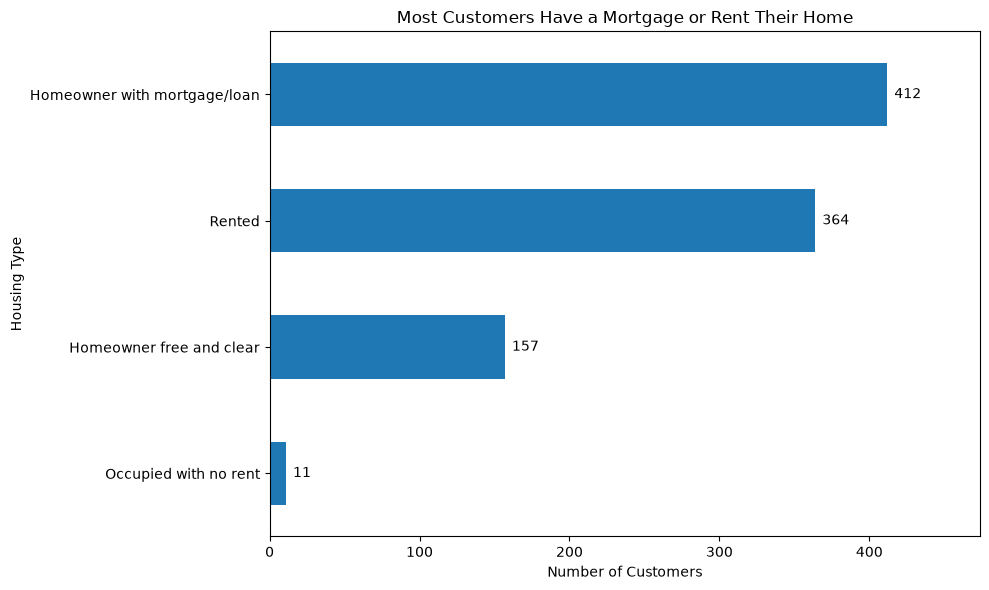

In [7]:

housing_counts = clean_df["housing.type"].value_counts()
housing_counts = housing_counts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

housing_counts.plot(kind="barh", ax=ax)

ax.bar_label(ax.containers[0], padding=5)

ax.set_title("Most Customers Have a Mortgage or Rent Their Home")
ax.set_xlabel("Number of Customers")
ax.set_ylabel("Housing Type")

ax.set_xlim(0, housing_counts.max() * 1.15)

plt.tight_layout()
plt.show()